In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow import keras
import ast
from sklearn.metrics import r2_score, mean_squared_error
from tensorflow import keras


In [12]:
# -------------------------
# CONFIGURAÇÕES GERAIS
# -------------------------
PREDICTORS = ["PwmD", "PwmE"]
TARGET = ["Wd", "We"]
INPUT_SIZE = len(PREDICTORS)  
OUTPUT_SIZE = len(TARGET) 
TIME_STEPS = 7
NDATASETS = 4  # ajuste se houver mais datasets

In [13]:
# -------------------------
# LEITURA DOS DATASETS
# -------------------------
Datasets = []
for i in range(NDATASETS):
    Dataset = pd.read_csv(f"../Dados/TestData/Data{i + 1}.csv")
    Dataset.index = (np.arange(0, len(Dataset)) * 0.07).round(5)
    Datasets.append(Dataset)
    print(f"++++++++++++++++++++ Dataset {i+1} +++++++++++++++++++++++")
    print(Dataset.head())

++++++++++++++++++++ Dataset 1 +++++++++++++++++++++++
        X    Y  Theta   Wd   We  WdRef  WeRef   PwmD   PwmE
0.00  0.0  0.7    0.0  0.0  0.0  -0.00   0.00  -0.00   0.00
0.07  0.0  0.7    0.0  0.0  0.0   3.28   3.28  -0.00   0.00
0.14  0.0  0.7    0.0  0.0  0.0   3.28   3.28  49.25  49.25
0.21  0.0  0.7    0.0  0.0  0.0   3.28   3.28  49.25  49.25
0.28  0.0  0.7    0.0  0.0  0.0   3.28   3.28  68.95  68.95
++++++++++++++++++++ Dataset 2 +++++++++++++++++++++++
        X    Y  Theta   Wd   We  WdRef  WeRef   PwmD   PwmE
0.00  0.0  0.7    0.0  0.0  0.0  -0.00   0.00  -0.00   0.00
0.07  0.0  0.7    0.0  0.0  0.0   3.02   3.02  -0.00   0.00
0.14  0.0  0.7    0.0  0.0  0.0   3.02   3.02  45.32  45.32
0.21  0.0  0.7    0.0  0.0  0.0   3.02   3.02  45.32  45.32
0.28  0.0  0.7    0.0  0.0  0.0   3.02   3.02  63.44  63.44
++++++++++++++++++++ Dataset 3 +++++++++++++++++++++++
        X    Y  Theta   Wd   We  WdRef  WeRef   PwmD   PwmE
0.00  0.0  0.7    0.0  0.0  0.0  -0.00   0.00  -0.00   

In [14]:
# -------------------------
# NORMALIZAÇÃO
# -------------------------
NormDatasets = []
SCALER = StandardScaler()
OUT_SCALER = StandardScaler()

TrainDataset = pd.read_csv(f"../Dados/Data1.csv")
SCALER.fit(TrainDataset[PREDICTORS])
OUT_SCALER.fit(TrainDataset[TARGET])

for i in range(NDATASETS):
    CurrentTestDataset = Datasets[i].copy()

    CurrentTestDataset[PREDICTORS] = SCALER.transform(CurrentTestDataset[PREDICTORS])
    CurrentTestDataset[TARGET] = OUT_SCALER.transform(CurrentTestDataset[TARGET])

    NormDatasets.append(CurrentTestDataset)
    print(f"++++++++++++++++++++ Dataset Normalizado {i+1} +++++++++++++++++++++++")
    print(NormDatasets[i].head())


++++++++++++++++++++ Dataset Normalizado 1 +++++++++++++++++++++++
        X    Y  Theta        Wd       We  WdRef  WeRef      PwmD      PwmE
0.00  0.0  0.7    0.0  0.107454  0.09236  -0.00   0.00  0.464323  0.399504
0.07  0.0  0.7    0.0  0.107454  0.09236   3.28   3.28  0.464323  0.399504
0.14  0.0  0.7    0.0  0.107454  0.09236   3.28   3.28  1.136042  0.929853
0.21  0.0  0.7    0.0  0.107454  0.09236   3.28   3.28  1.136042  0.929853
0.28  0.0  0.7    0.0  0.107454  0.09236   3.28   3.28  1.404730  1.141992
++++++++++++++++++++ Dataset Normalizado 2 +++++++++++++++++++++++
        X    Y  Theta        Wd       We  WdRef  WeRef      PwmD      PwmE
0.00  0.0  0.7    0.0  0.107454  0.09236  -0.00   0.00  0.464323  0.399504
0.07  0.0  0.7    0.0  0.107454  0.09236   3.02   3.02  0.464323  0.399504
0.14  0.0  0.7    0.0  0.107454  0.09236   3.02   3.02  1.082441  0.887533
0.21  0.0  0.7    0.0  0.107454  0.09236   3.02   3.02  1.082441  0.887533
0.28  0.0  0.7    0.0  0.107454  0.09236 

In [15]:
# -------------------------
# FUNÇÃO PARA CRIAR SEQUÊNCIAS
# -------------------------
def CreateSequences(input_data, target_data, timesteps):
    X_seq, Y_seq = [], []
    for i in range(timesteps, len(input_data)):
        X_seq.append(input_data.iloc[i - timesteps:i].values)
        Y_seq.append(target_data.iloc[i].values)
    return np.array(X_seq), np.array(Y_seq)

# Odometria 

- R = 0.034    Raio da roda (m)
- L = 0.147/2  Distância entre rodas (m)
- T = 0.07     Período de amostragem (s)

- $x_{k+1} = x_k + \frac{R . T}{2} . (\phi_d[k] + \phi_e[k]) \cos(\theta_k)$

- $  y_{k+1} = y_k + \frac{R . T}{2} . (\phi_d[k] + \phi_e[k]) \sin(\theta_k)  $

- $ \theta_{k+1} = \theta_k + \frac{R . T}{2L} . (\phi_d[k] - \phi_e[k]) $



In [16]:
R = 0.032   
L = 0.124 
T = 0.07   

def Odometry(Wd, We, x0=0, y0=0.7, theta0=0):

    n = len(Wd)
    X_est, Y_est, Theta_est = [x0], [y0], [theta0]

    for k in range(n - 1):
        theta_k = Theta_est[-1]

        # Cinemática diferencial
        x_next = X_est[-1] + (R * T / 2) * (np.cos(theta_k) * (Wd[k] + We[k]))
        y_next = Y_est[-1] + (R * T / 2) * (np.sin(theta_k) * (Wd[k] + We[k]))
        theta_next = Theta_est[-1] + (R * T / (2 * L)) * (Wd[k] - We[k])

        X_est.append(x_next)
        Y_est.append(y_next)
        Theta_est.append(theta_next)

    return np.array(X_est), np.array(Y_est), np.array(Theta_est)



In [17]:
import matplotlib.pyplot as plt
import numpy as np

def PlotTrajectoryEvolution(X_true, Y_true, Theta_true, X_est, Y_est, Theta_est, title):
    """
    Exibe 3 gráficos discretos (X, Y, Θ) em função do tempo (ou iteração k).
    Cada gráfico mostra amostras reais e estimadas.
    """
    k = np.arange(len(X_true))
    time = (k * T).round(5)

    fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

    # --- X ---
    axs[0].scatter(time, X_true, marker='o', s=15, label='X verdadeiro', color='blue', alpha=0.7)
    axs[0].scatter(time, X_est, marker='x', s=15, label='X estimado', color='red', alpha=0.7)
    axs[0].set_ylabel('X [m]')
    axs[0].legend()
    axs[0].grid(True)

    # --- Y ---
    axs[1].scatter(time, Y_true, marker='o', s=15, label='Y verdadeiro', color='blue', alpha=0.7)
    axs[1].scatter(time, Y_est, marker='x', s=15, label='Y estimado', color='red', alpha=0.7)
    axs[1].set_ylabel('Y [m]')
    axs[1].legend()
    axs[1].grid(True)

    # --- Theta ---
    axs[2].scatter(time, Theta_true, marker='o', s=15, label=r'$\theta$ verdadeiro', color='blue', alpha=0.7)
    axs[2].scatter(time, Theta_est, marker='x', s=15, label=r'$\theta$ estimado', color='red', alpha=0.7)
    axs[2].set_xlabel('Tempo [s]')
    axs[2].set_ylabel(r'$\theta$ [rad]')
    axs[2].legend()
    axs[2].grid(True)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


In [18]:
# -------------------------
# SELECIONA OS 5 MELHORES MODELOS
# -------------------------
SORT_BY = "R2_Test_We"  # coluna usada para classificar os modelos

results_df = pd.read_excel("./resultados.xlsx")
results_df = results_df.sort_values(SORT_BY, ascending=False)
ModelsConfs = results_df.head(4).reset_index(drop=True)

print("+++++ Top 4 modelos selecionados +++++")
display(ModelsConfs)

+++++ Top 4 modelos selecionados +++++


,model,Neurons,R2_Train_Wd,MSE_Train_Wd,R2_Val_Wd,MSE_Val_Wd,R2_Test_Wd,MSE_Test_Wd,R2_Train_We,MSE_Train_We,R2_Val_We,MSE_Val_We,R2_Test_We,MSE_Test_We,W0,Wf
0,model_16_9,16,[0.92318624011083],[0.286989926150127],[0.9533673592939406],[0.19873868735248865],[0.934727899865458],[0.3405269755258593],[0.9409741196860679],[0.2124870573463732],[0.9501154162133543],[0.21126469015256977],[0.9179926502069188],[0.4385364863992883],"[[[-0.06440000236034393, -0.027699999511241913...","[[[0.04610000178217888, 0.03739999979734421, -..."
1,model_16_0,16,[0.9219070101830469],[0.2917693576352304],[0.9363254784329212],[0.27136766527559353],[0.9097057729196542],[0.47106834300929273],[0.9449686836231828],[0.19810704078643185],[0.9512541166435255],[0.206442214443729],[0.9147390277371099],[0.4559353191817149],"[[[0.003599999938160181, -0.017000000923871994...","[[[0.09470000118017197, -0.03920000046491623, ..."
2,model_12_1,12,[0.9232748784391025],[0.2866587575245875],[0.9525947682397509],[0.20203131092355728],[0.9317987493001458],[0.3558084630344525],[0.9377393499041314],[0.22413189361990224],[0.9499138775124751],[0.2121182206015173],[0.9126206323308305],[0.46726349501739545],"[[[-0.020999999716877937, 0.13940000534057617,...","[[[-0.133200004696846, 0.1818999946117401, -0...."
3,model_5_9,5,[0.9229356303521097],[0.2879275709227432],[0.9457426487514847],[0.2308740917073079],[0.9302354048663175],[0.3632444385155329],[0.9342976563556197],[0.23618995944941035],[0.9500726987184065],[0.21117192946453736],[0.9110286697078315],[0.4748168661307898],"[[[-0.020800000056624413, 0.07909999787807465,...","[[[0.2046000063419342, 0.5429999828338623, 0.3..."




===== Avaliando Dataset 1 =====
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

===== model_16_9 =====
R2_X = -1.1833, MSE_X = 0.221426
R2_Y = -1.8673, MSE_Y = 0.228459
R2_Theta = -10.1832, MSE_Theta = 3.151801


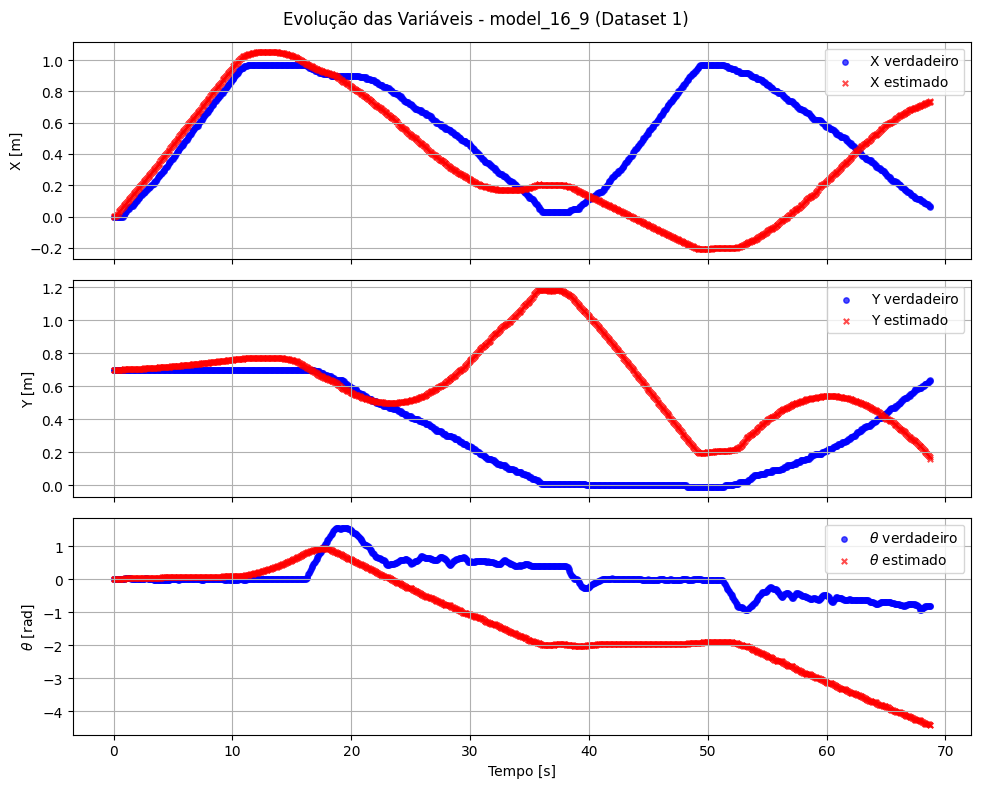

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

===== model_16_0 =====
R2_X = -3.2350, MSE_X = 0.429515
R2_Y = -1.6369, MSE_Y = 0.210102
R2_Theta = -59.7202, MSE_Theta = 17.112934


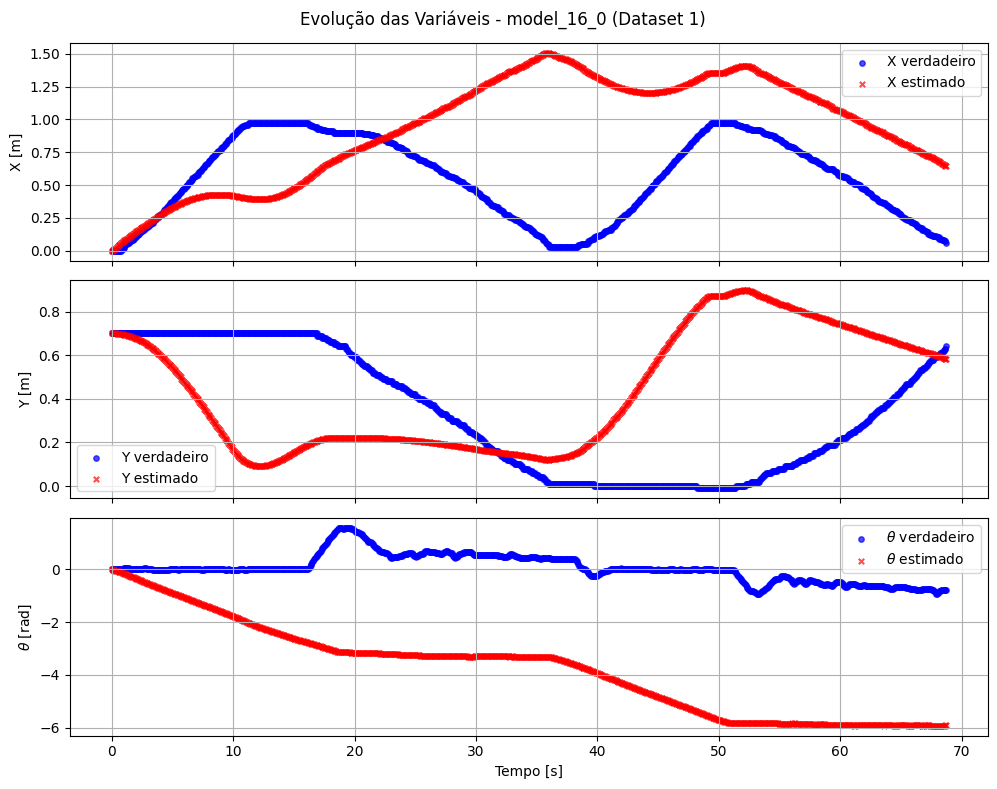

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

===== model_12_1 =====
R2_X = 0.4347, MSE_X = 0.057334
R2_Y = -0.8912, MSE_Y = 0.150690
R2_Theta = -1.1759, MSE_Theta = 0.613245


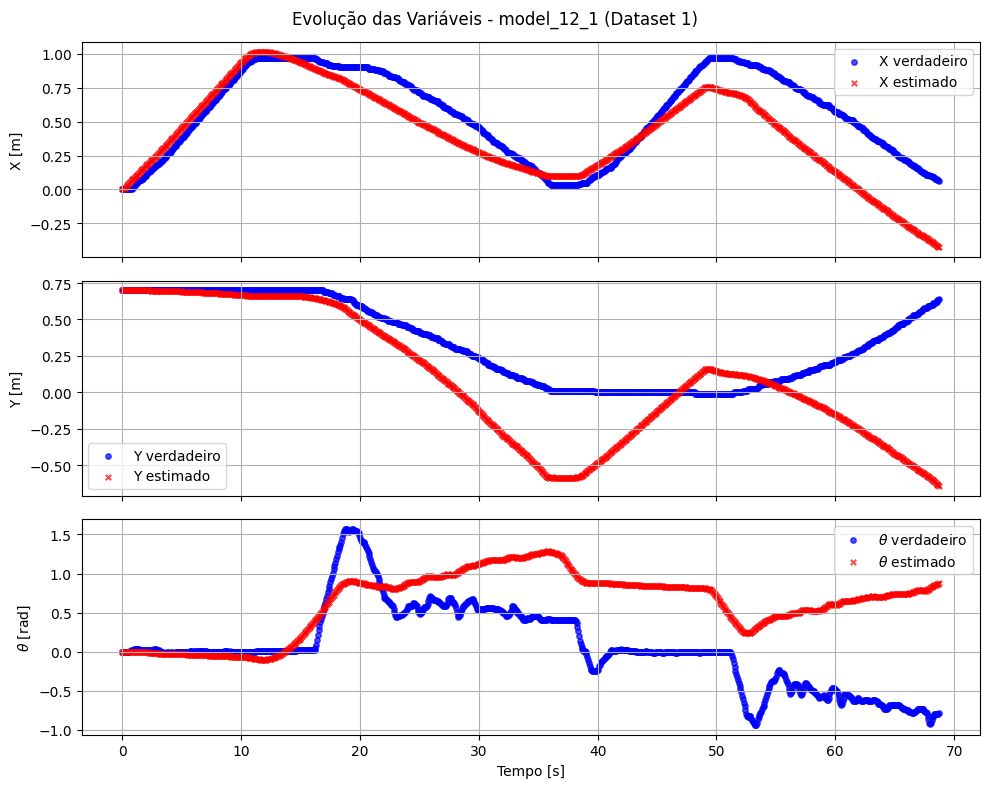

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

===== model_5_9 =====
R2_X = 0.9276, MSE_X = 0.007338
R2_Y = 0.1146, MSE_Y = 0.070547
R2_Theta = 0.4373, MSE_Theta = 0.158599


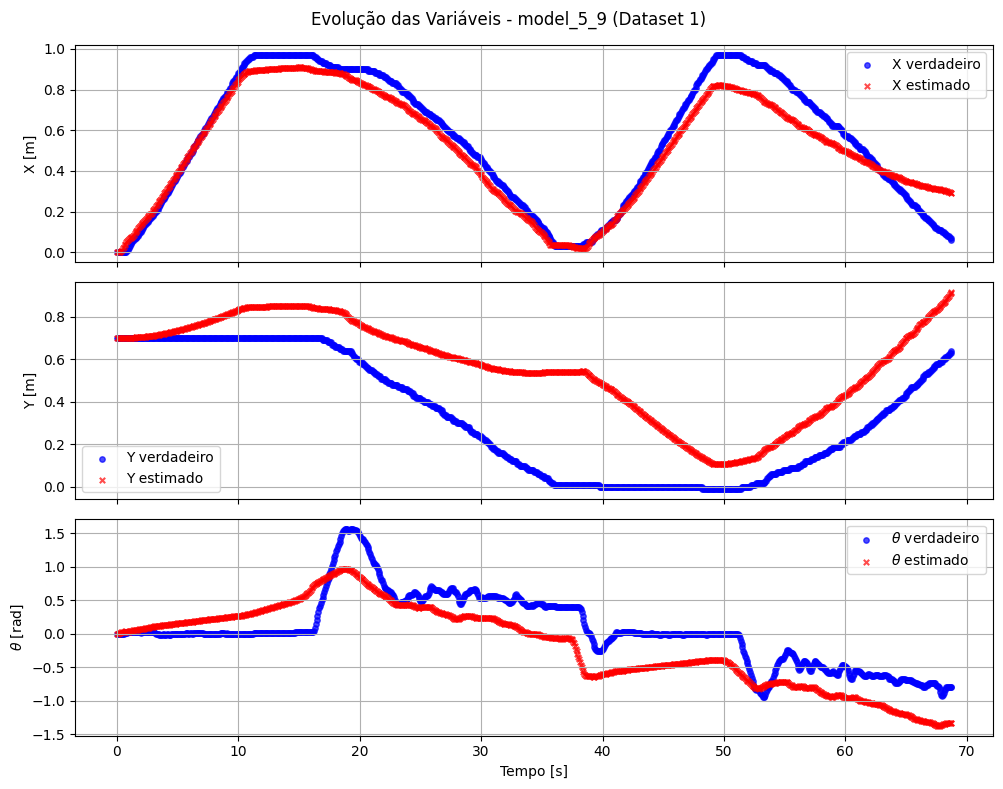



===== Avaliando Dataset 2 =====
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

===== model_16_9 =====
R2_X = -51.7458, MSE_X = 4.915410
R2_Y = -30.0959, MSE_Y = 1.627206
R2_Theta = -0.3896, MSE_Theta = 4.105134


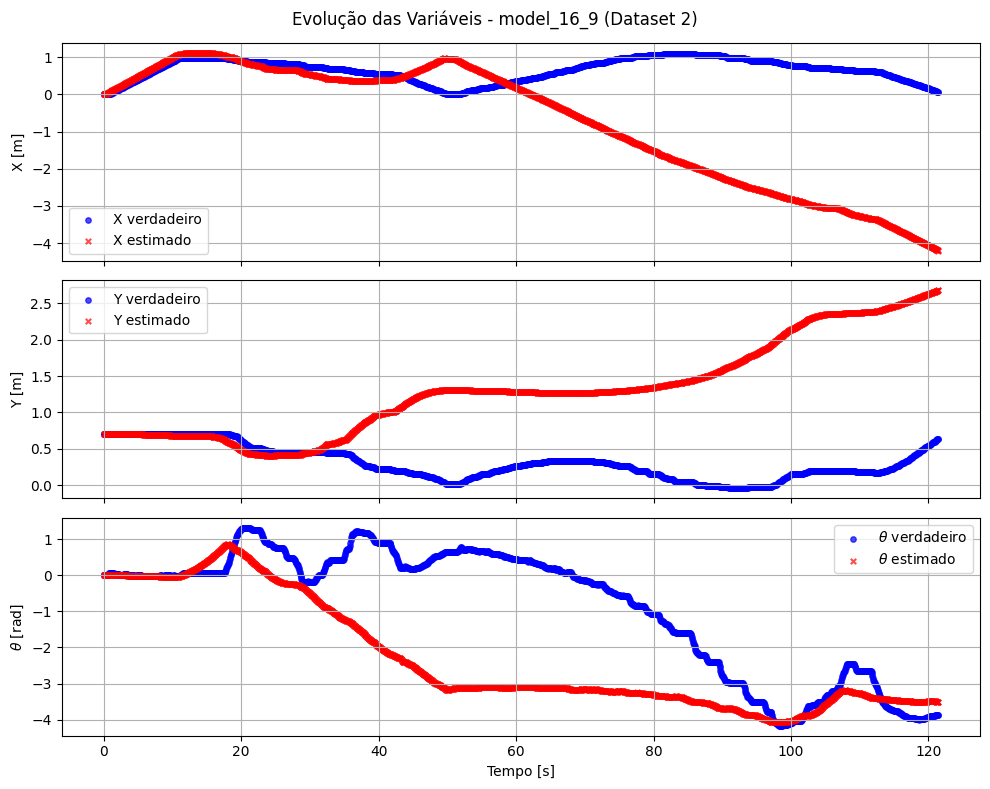

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

===== model_16_0 =====
R2_X = -10.9352, MSE_X = 1.112251
R2_Y = -1.5962, MSE_Y = 0.135853
R2_Theta = -18.0180, MSE_Theta = 56.181784


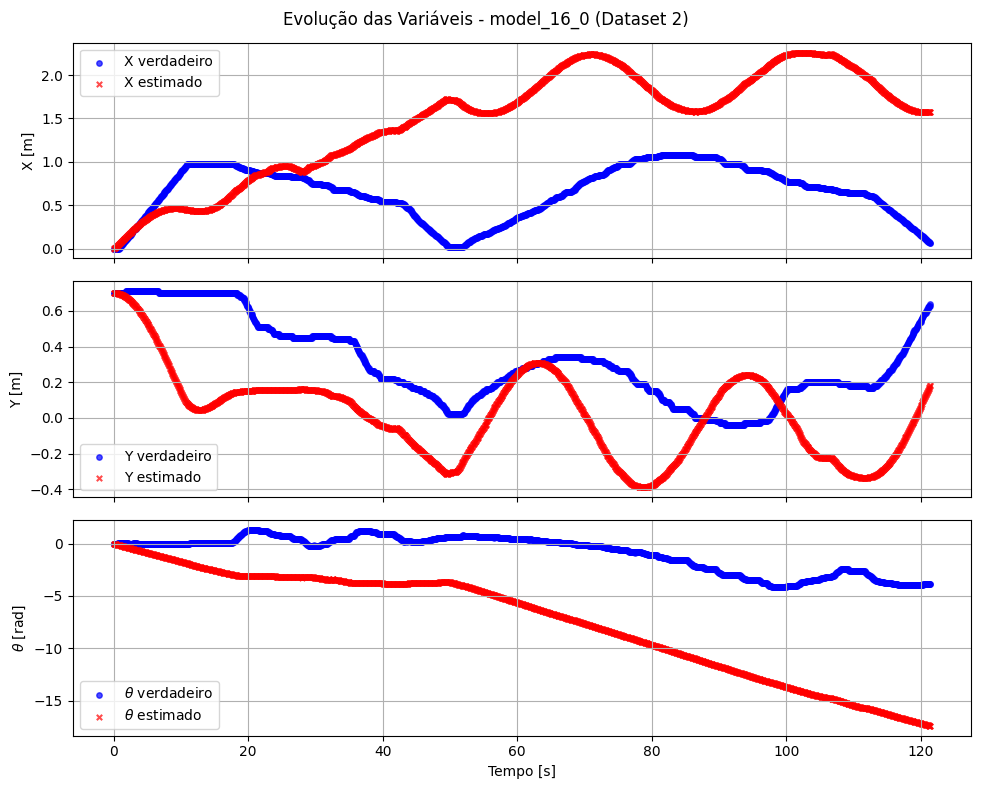

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

===== model_12_1 =====
R2_X = -5.9968, MSE_X = 0.652039
R2_Y = -6.5595, MSE_Y = 0.395577
R2_Theta = 0.1769, MSE_Theta = 2.431576


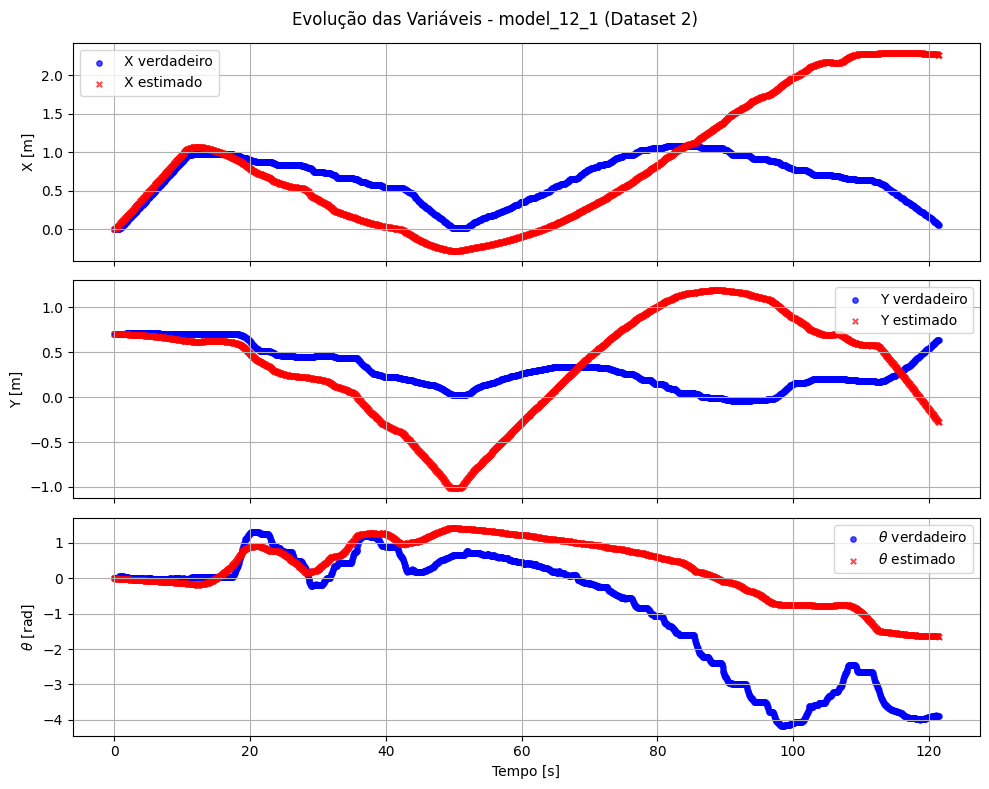

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

===== model_5_9 =====
R2_X = -7.6219, MSE_X = 0.803483
R2_Y = -7.4830, MSE_Y = 0.443906
R2_Theta = 0.1894, MSE_Theta = 2.394508


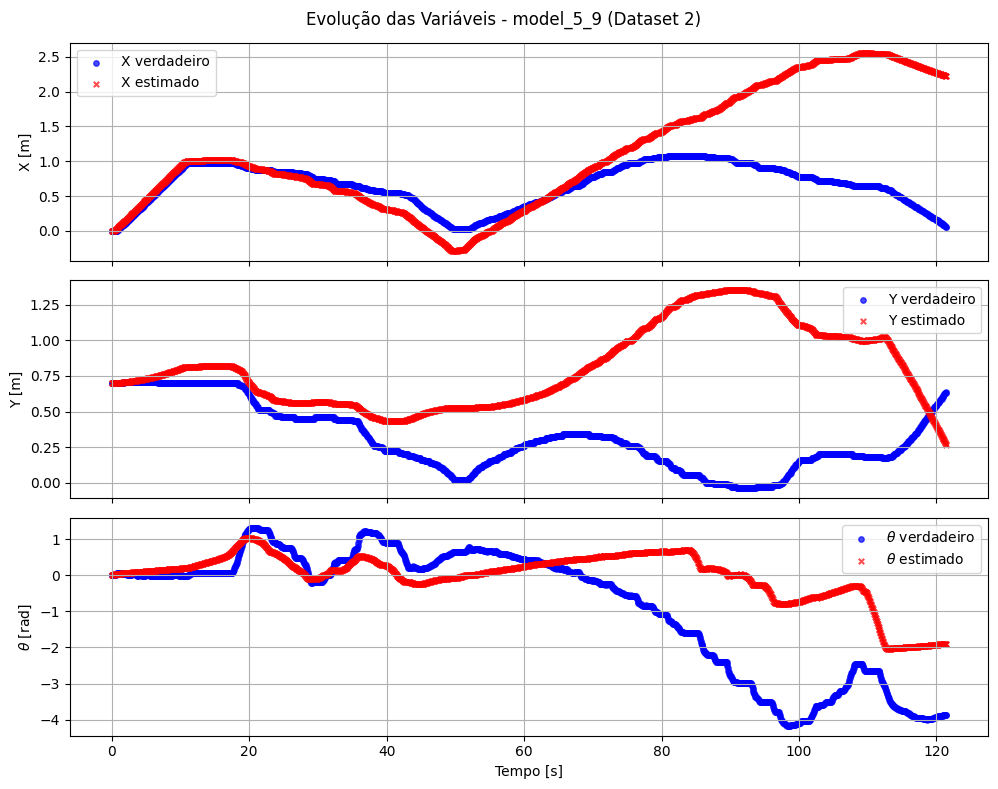



===== Avaliando Dataset 3 =====
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

===== model_16_9 =====
R2_X = -0.3165, MSE_X = 0.104623
R2_Y = -2.2194, MSE_Y = 0.190773
R2_Theta = -64.9711, MSE_Theta = 26.340088


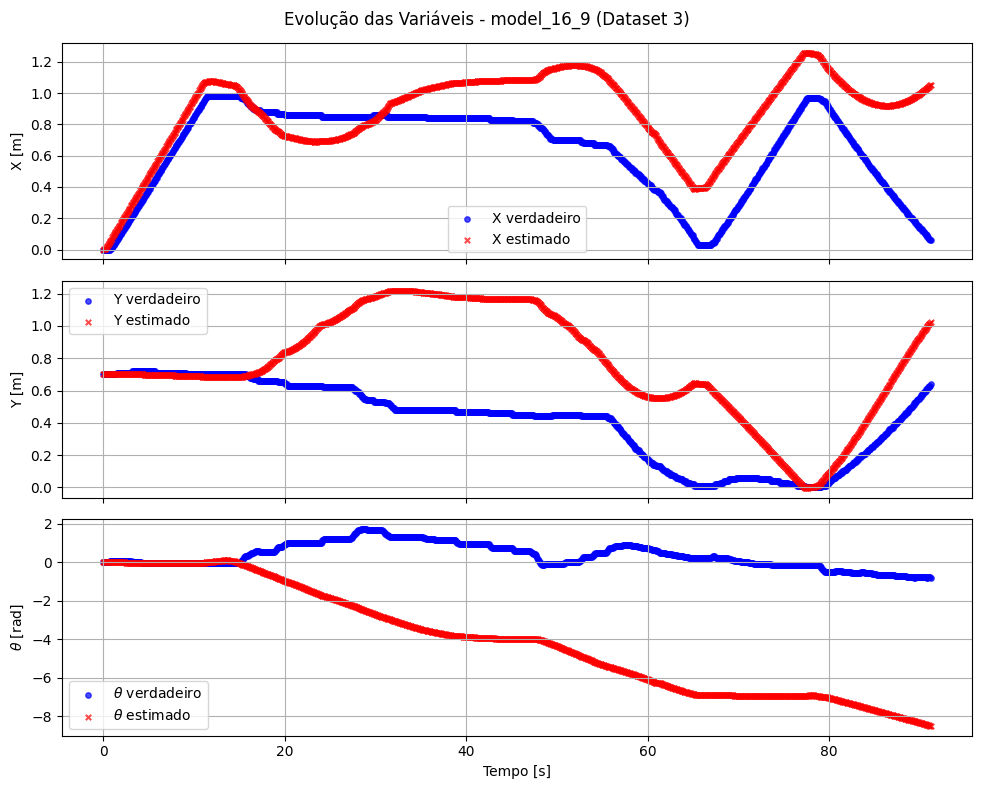

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

===== model_16_0 =====
R2_X = -2.1694, MSE_X = 0.251878
R2_Y = -1.0155, MSE_Y = 0.119430
R2_Theta = -59.1767, MSE_Theta = 24.026581


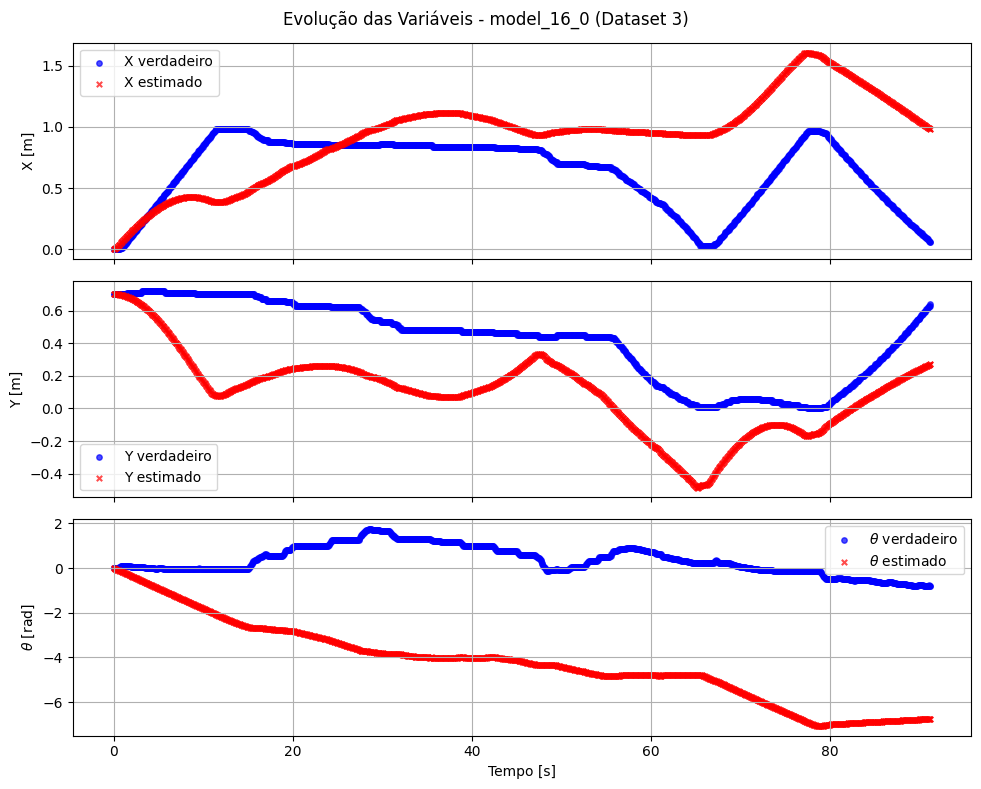

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

===== model_12_1 =====
R2_X = -3.8454, MSE_X = 0.385074
R2_Y = -5.6284, MSE_Y = 0.392773
R2_Theta = 0.2152, MSE_Theta = 0.313327


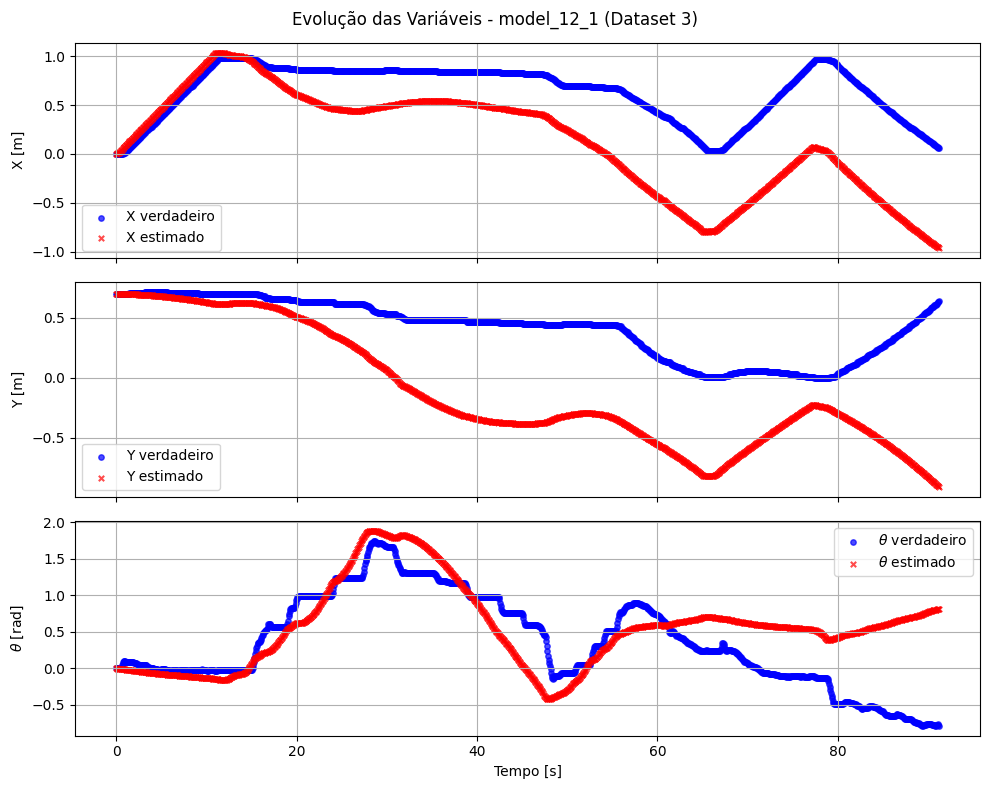

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

===== model_5_9 =====
R2_X = 0.3385, MSE_X = 0.052569
R2_Y = -2.0673, MSE_Y = 0.181755
R2_Theta = -0.9903, MSE_Theta = 0.794680


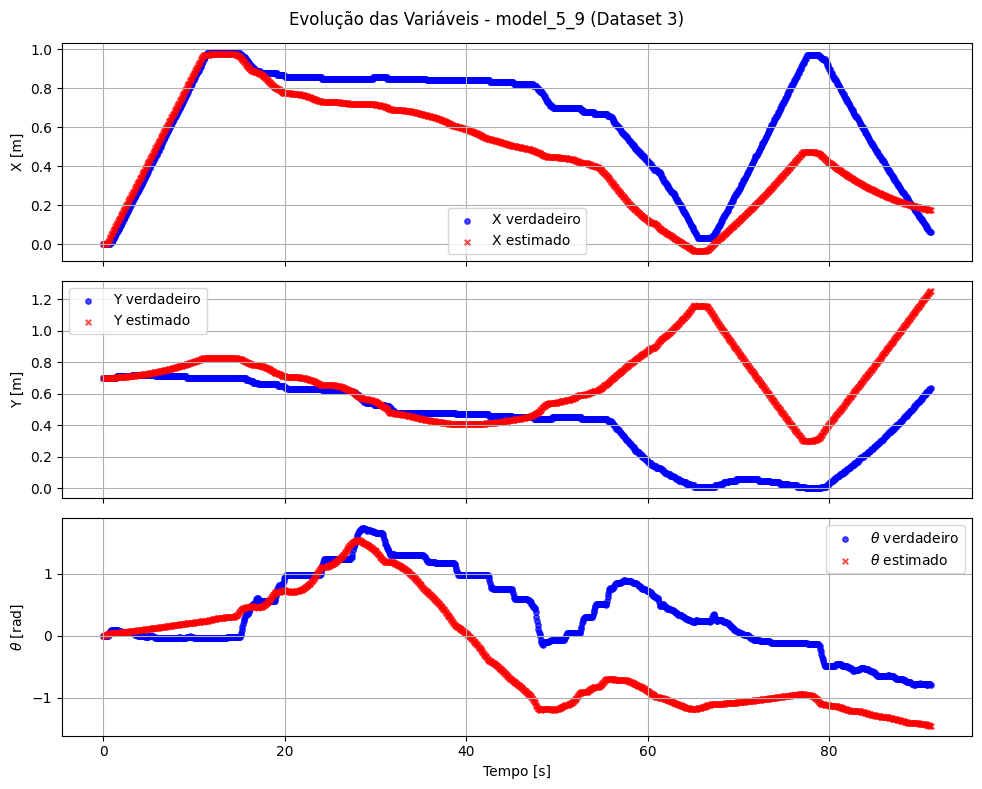



===== Avaliando Dataset 4 =====
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

===== model_16_9 =====
R2_X = -3.1546, MSE_X = 0.385404
R2_Y = -14.2586, MSE_Y = 1.129077
R2_Theta = -35.8599, MSE_Theta = 12.217119


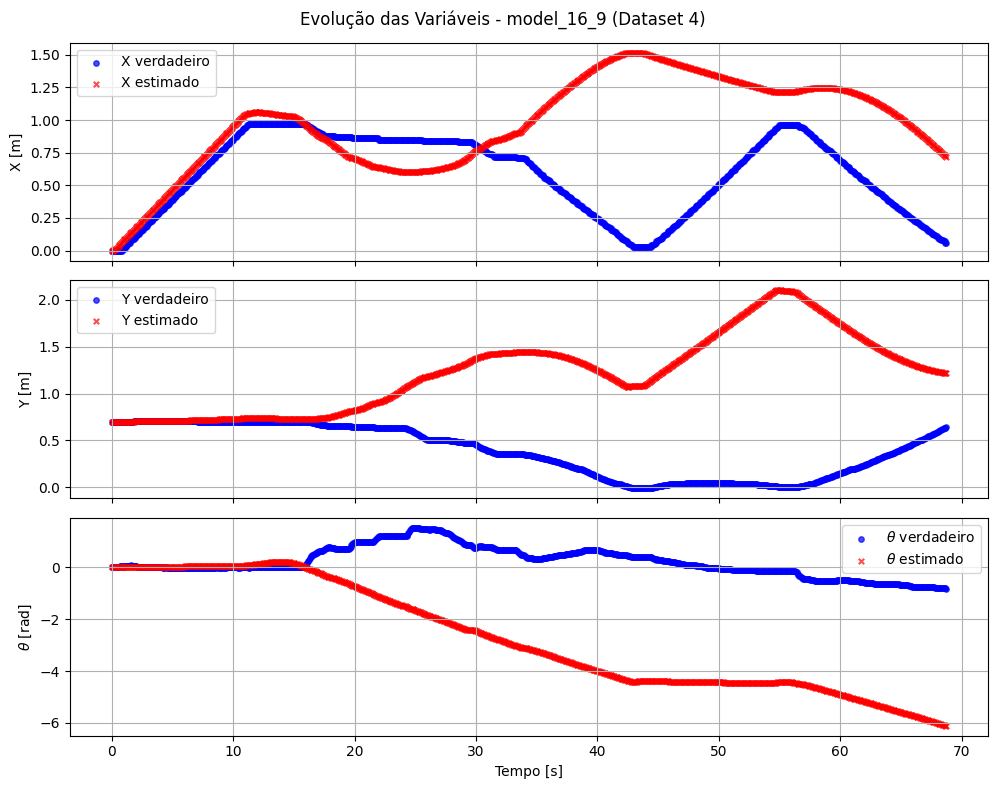

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

===== model_16_0 =====
R2_X = -5.0315, MSE_X = 0.559525
R2_Y = -1.1421, MSE_Y = 0.158506
R2_Theta = -44.6331, MSE_Theta = 15.124976


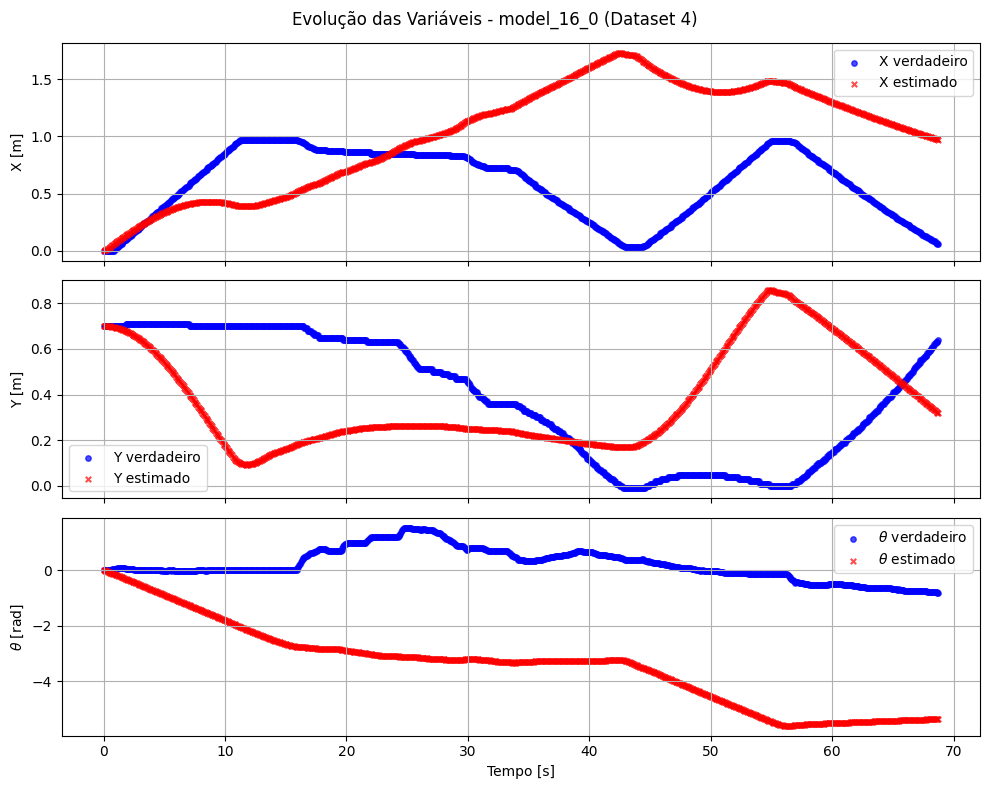

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

===== model_12_1 =====
R2_X = -0.0948, MSE_X = 0.101560
R2_Y = -5.7804, MSE_Y = 0.501721
R2_Theta = -2.9745, MSE_Theta = 1.317329


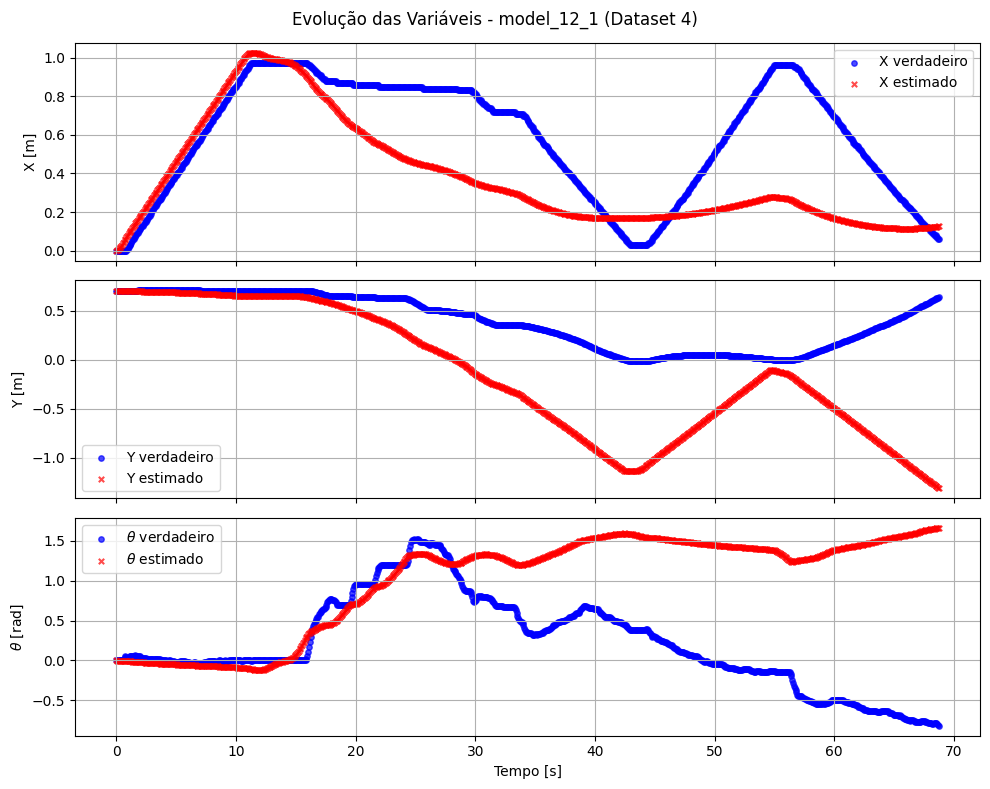

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

===== model_5_9 =====
R2_X = 0.8181, MSE_X = 0.016871
R2_Y = 0.6163, MSE_Y = 0.028393
R2_Theta = 0.4072, MSE_Theta = 0.196479


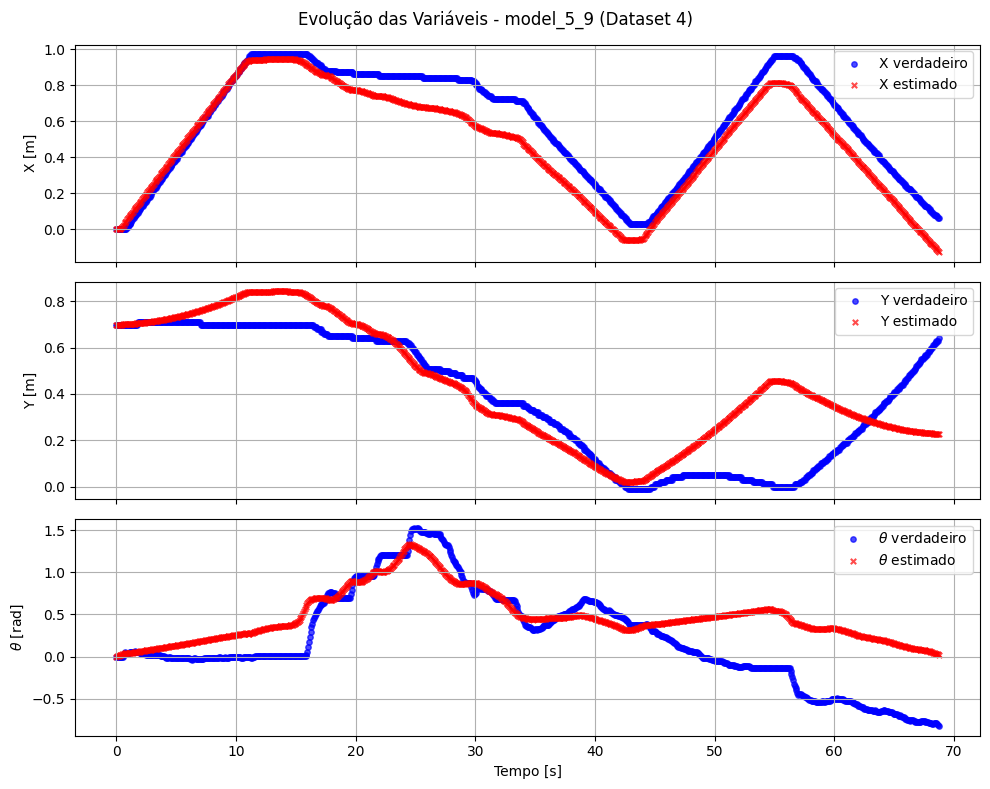

In [19]:
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error

# -------------------------
# RECONSTRUÇÃO E AVALIAÇÃO
# -------------------------

results = []  # lista para armazenar métricas

# Correção: iteração simultânea deve usar zip()
for i, (NormDataset, Dataset) in enumerate(zip(NormDatasets, Datasets)):
    x_test, y_test = CreateSequences(NormDataset[PREDICTORS], NormDataset[TARGET], TIME_STEPS)
    Wd_We_true = OUT_SCALER.inverse_transform(y_test)

    X_true = Dataset["X"].values
    Y_true = Dataset["Y"].values
    Theta_true = Dataset["Theta"].values

    print(f"\n\n===== Avaliando Dataset {i+1} =====")

    for idx, ModelConf in ModelsConfs.iterrows():
        n = int(ModelConf["Neurons"])
        Name = ModelConf["model"]

        # --- Carrega pesos do modelo ---
        Wf = [np.array(w) for w in ast.literal_eval(ModelConf["Wf"])]

        model = keras.models.Sequential([
            keras.layers.Input(shape=(TIME_STEPS, INPUT_SIZE)),
            keras.layers.SimpleRNN(n, activation="tanh"),
            keras.layers.Dense(OUTPUT_SIZE, activation="linear")
        ])
        model.set_weights(Wf)

        # --- Faz predição ---
        Wd_We_pred = OUT_SCALER.inverse_transform(model.predict(x_test))

        # --- Extrai velocidades previstas ---
        Wd_pred = Wd_We_pred[:, 0]   # ωd (roda direita)
        We_pred = Wd_We_pred[:, 1]   # ωe (roda esquerda)

        # --- Calcula odometria estimada ---
        X_est, Y_est, Theta_est = Odometry(Wd_pred, We_pred)

        # Garante que os tamanhos batem
        min_len = min(len(X_true), len(X_est))
        X_true, Y_true, Theta_true = X_true[:min_len], Y_true[:min_len], Theta_true[:min_len]
        X_est, Y_est, Theta_est = X_est[:min_len], Y_est[:min_len], Theta_est[:min_len]

        # --- Cálculo das métricas ---
        r2_x = r2_score(X_true, X_est)
        r2_y = r2_score(Y_true, Y_est)
        r2_theta = r2_score(Theta_true, Theta_est)

        mse_x = mean_squared_error(X_true, X_est)
        mse_y = mean_squared_error(Y_true, Y_est)
        mse_theta = mean_squared_error(Theta_true, Theta_est)

        print(f"\n===== {Name} =====")
        print(f"R2_X = {r2_x:.4f}, MSE_X = {mse_x:.6f}")
        print(f"R2_Y = {r2_y:.4f}, MSE_Y = {mse_y:.6f}")
        print(f"R2_Theta = {r2_theta:.4f}, MSE_Theta = {mse_theta:.6f}")

        # --- Armazena resultados ---
        results.append({
            "Dataset": i + 1,
            "Model": Name,
            "Neurons": n,
            "R2_X": r2_x, "MSE_X": mse_x,
            "R2_Y": r2_y, "MSE_Y": mse_y,
            "R2_Theta": r2_theta, "MSE_Theta": mse_theta
        })

        # --- Gera gráfico ---
        PlotTrajectoryEvolution(
            X_true, Y_true, Theta_true,
            X_est, Y_est, Theta_est,
            f"Evolução das Variáveis - {Name} (Dataset {i+1})"
        )
        
results_df = pd.DataFrame(results)
results_df.to_excel("Odometry.xlsx")


In [20]:
results_df.to_csv("odometry.csv")